--- 1. 数据加载与预处理 ---
数据集加载成功，形状为: (3959, 5)
添加偏置项后特征矩阵X_b的形状: (3959, 5)
训练集X_train形状: (3000, 5), y_train形状: (3000, 1)
测试集X_test形状: (959, 5), y_test形状: (959, 1)

--- 2. 随机梯度下降线性回归训练 ---
初始模型参数theta的形状: (5, 1)
随机种子已设置为: 100
开始训练，学习率: 0.0001, Epochs: 50
Epoch 5/50, Cost: 0.4515
Epoch 10/50, Cost: 0.4113
Epoch 15/50, Cost: 0.3986
Epoch 20/50, Cost: 0.4134
Epoch 25/50, Cost: 0.4712
Epoch 30/50, Cost: 0.3878
Epoch 35/50, Cost: 0.4025
Epoch 40/50, Cost: 0.3922
Epoch 45/50, Cost: 0.3994
Epoch 50/50, Cost: 0.4206

训练完成！
最终模型参数theta:
[[ 0.05820225]
 [-0.01391894]
 [ 0.58662066]
 [ 0.11612682]
 [ 0.28454714]]

--- 3. 绘制均方误差代价函数曲线 ---


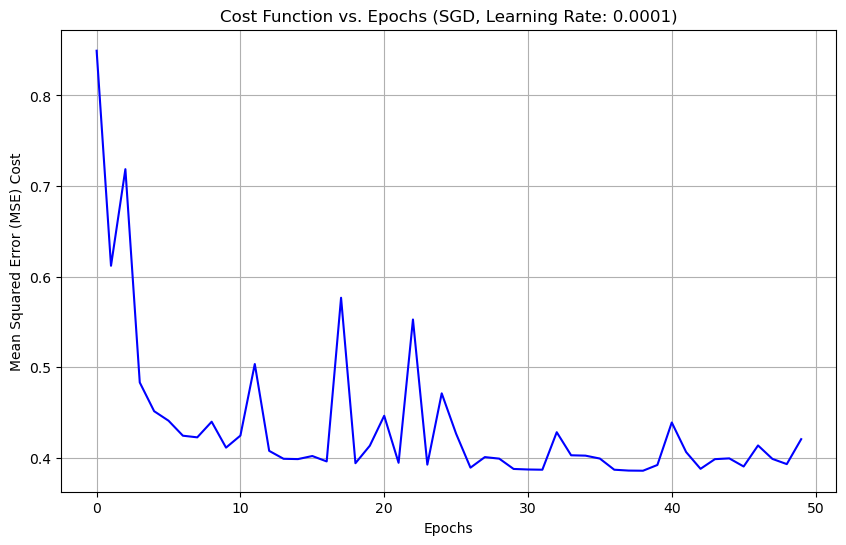


--- 4. 模型评估 (计算RMSE) ---
训练集上的均方误差 (MSE): 0.8413
训练集上的均方根误差 (RMSE): 0.9172
测试集上的均方误差 (MSE): 0.7391
测试集上的均方根误差 (RMSE): 0.8597


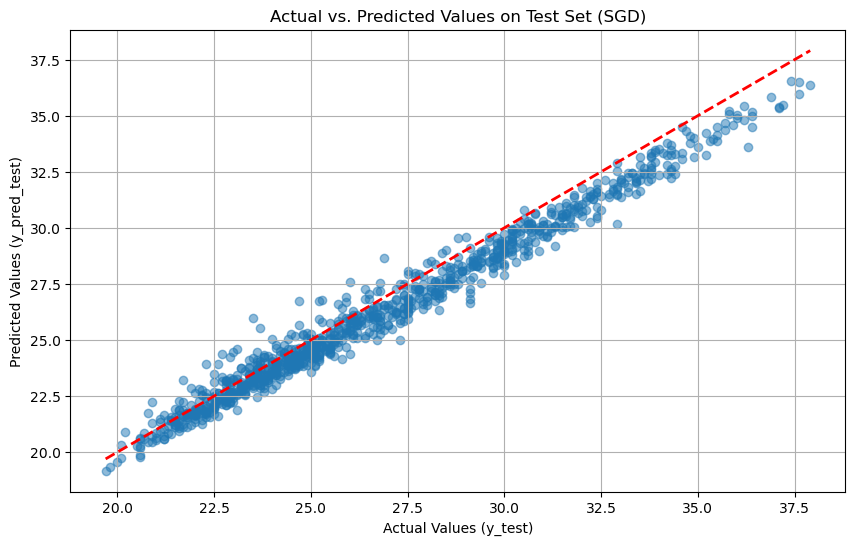


--- 5. 改变随机种子、学习率和Epochs的提示 ---
你可以尝试修改代码中的 `random_seed`, `learning_rate` 和 `n_epochs` 值，例如：
  - `random_seed = 42` (不同的种子)
  - `learning_rate = 0.005` 或 `0.05` (更高或更低)
  - `n_epochs = 20` 或 `100` (更少或更多)
观察代价函数曲线、RMSE值以及模型收敛的速度和效果。
对于SGD，学习率的选择非常关键，过高可能导致震荡或发散，过低则收敛缓慢。
随机种子会影响样本的选取顺序，从而影响训练过程和最终结果的微小差异。


In [5]:
# Textbook: Principles and Practices of Machine Learning
# Experiment 2-3: Linear Regression with Stochastic Gradient Descent & Evaluation
# Author: Zhe Chen (ml_iot@163.com), 2021 (Modified by ChatGPT)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- 解决中文显示问题 (已将所有中文标签替换为英文，所以此处无需特殊字体配置) ---
# 请确保以下两行代码被注释掉或删除，否则Matplotlib会尝试寻找这些字体
# plt.rcParams['font.sans-serif'] = ['WenQuanYi Micro Hei', 'SimHei', 'sans-serif']
# plt.rcParams['axes.unicode_minus'] = False
# ----------------------------------------------------------------------------------

# --- 1. 数据加载与预处理 ---
print("--- 1. 数据加载与预处理 ---")
# load dataset
try:
    df = pd.read_csv('temperature_dataset.csv')
    data = np.array(df)
    print(f"数据集加载成功，形状为: {data.shape}")
except FileNotFoundError:
    print("错误：未找到 'temperature_dataset.csv' 文件。")
    print("请确保该文件与Python脚本在同一目录下，并包含至少5列温度数据。")
    print("你可以使用以下代码生成一个示例文件：")
    print("""
import numpy as np
import pandas as pd
np.random.seed(42)
# 生成3960行，5列的随机温度数据 (15到25度之间)
data_gen = np.random.rand(3960, 5) * 10 + 15 
df_gen = pd.DataFrame(data_gen, columns=[f'temp_sensor_{i+1}' for i in range(5)])
df_gen.to_csv('temperature_dataset.csv', index=False)
print('已生成示例文件 temperature_dataset.csv')
    """)
    exit() # 退出程序

# 划分特征 (X) 和标签 (y)
# 提示：将传感器2-5作为4维输入特征(X)
# 提示：将传感器1作为标签(y)
X = data[:, 1:5]  # 索引1,2,3,4对应第2-5列
y = data[:, 0]    # 索引0对应第1列

# 确保y是列向量
y = y.reshape(-1, 1)

# 为特征矩阵X添加偏置项
# 在X的第一列添加一列1，对应截距项theta_0
X_b = np.c_[np.ones((X.shape[0], 1)), X]
print(f"添加偏置项后特征矩阵X_b的形状: {X_b.shape}")

# 划分为训练集和测试集
# 提示：前3000个样本用于训练，剩余960个用于测试
train_size = 3000
test_size = 960

X_train = X_b[:train_size]
y_train = y[:train_size]
X_test = X_b[train_size:train_size + test_size]
y_test = y[train_size:train_size + test_size]

print(f"训练集X_train形状: {X_train.shape}, y_train形状: {y_train.shape}")
print(f"测试集X_test形状: {X_test.shape}, y_test形状: {y_test.shape}")

# --- 2. 随机梯度下降线性回归训练 ---
print("\n--- 2. 随机梯度下降线性回归训练 ---")

# 初始化模型参数
n_features = X_train.shape[1]
theta = np.random.randn(n_features, 1) # 随机初始化theta
print(f"初始模型参数theta的形状: {theta.shape}")

# 设置随机种子 (用于可复现性)
random_seed = 100
rng = np.random.default_rng(random_seed)
print(f"随机种子已设置为: {random_seed}")

# 设置随机梯度下降参数
learning_rate = 0.0001   # SGD通常需要不同的学习率，可能比BGD大
n_epochs = 50          # 遍历整个训练集的次数
m = len(y_train)       # 训练样本数量

# 存储每个epoch结束时的代价函数值用于绘图
cost_history = []
# 存储每个epoch结束时的theta，如果需要绘制直线变化 (选做)
# theta_history = [] 

print(f"开始训练，学习率: {learning_rate}, Epochs: {n_epochs}")

# 创建一个索引数组，用于打乱训练样本顺序
indices = np.arange(m)

for epoch in range(n_epochs):
    # 在每个epoch开始时，随机打乱训练样本的顺序
    rng.shuffle(indices)

    for i in range(m): # 遍历每个训练样本
        # 获取当前随机选择的样本
        random_idx = indices[i]
        xi = X_train[random_idx:random_idx+1] # 保持二维形状 (1, n_features)
        yi = y_train[random_idx:random_idx+1] # 保持二维形状 (1, 1)

        # 计算预测值
        prediction = xi @ theta

        # 计算误差
        error = prediction - yi

        # 计算梯度 (对于单个样本，没有1/m)
        gradients = xi.T @ error

        # 更新模型参数theta
        theta = theta - learning_rate * gradients
    
    # 在每个epoch结束时，计算整个训练集的MSE作为代价函数值
    # 这使得代价函数曲线更平滑，更易于观察趋势
    predictions_epoch_end = X_train @ theta
    errors_epoch_end = predictions_epoch_end - y_train
    cost_epoch = (1/(2*m)) * np.sum(errors_epoch_end**2)
    cost_history.append(cost_epoch)
    # theta_history.append(theta.copy()) # 如果需要绘制直线变化，则取消注释

    if (epoch + 1) % (n_epochs / 10) == 0:
        print(f"Epoch {epoch + 1}/{n_epochs}, Cost: {cost_epoch:.4f}")

print("\n训练完成！")
print("最终模型参数theta:")
print(theta)

# --- 3. 绘制均方误差代价函数曲线 ---
print("\n--- 3. 绘制均方误差代价函数曲线 ---")

plt.figure(figsize=(10, 6))
plt.plot(range(n_epochs), cost_history, color='blue', linestyle='-')
plt.xlabel('Epochs') # X轴现在是Epochs
plt.ylabel('Mean Squared Error (MSE) Cost') # 英文
plt.title(f'Cost Function vs. Epochs (SGD, Learning Rate: {learning_rate})') # 英文
plt.grid(True)
plt.show()

# --- 4. 模型评估 (计算RMSE) ---
print("\n--- 4. 模型评估 (计算RMSE) ---")

# 在训练集上评估模型性能
y_pred_train = X_train @ theta
train_mse = np.mean((y_pred_train - y_train)**2)
train_rmse = np.sqrt(train_mse) # 计算训练集RMSE
print(f"训练集上的均方误差 (MSE): {train_mse:.4f}")
print(f"训练集上的均方根误差 (RMSE): {train_rmse:.4f}")

# 在测试集上评估模型性能
y_pred_test = X_test @ theta
test_mse = np.mean((y_pred_test - y_test)**2)
test_rmse = np.sqrt(test_mse) # 计算测试集RMSE
print(f"测试集上的均方误差 (MSE): {test_mse:.4f}")
print(f"测试集上的均方根误差 (RMSE): {test_rmse:.4f}")


# 绘制预测值与实际值 (测试集)
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_test, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # 对角线
plt.xlabel('Actual Values (y_test)') # 英文
plt.ylabel('Predicted Values (y_pred_test)') # 英文
plt.title('Actual vs. Predicted Values on Test Set (SGD)') # 英文
plt.grid(True)
plt.show()

# --- 5. 改变随机种子、学习率和Epochs的提示 ---
print("\n--- 5. 改变随机种子、学习率和Epochs的提示 ---")
print("你可以尝试修改代码中的 `random_seed`, `learning_rate` 和 `n_epochs` 值，例如：")
print("  - `random_seed = 42` (不同的种子)")
print("  - `learning_rate = 0.005` 或 `0.05` (更高或更低)")
print("  - `n_epochs = 20` 或 `100` (更少或更多)")
print("观察代价函数曲线、RMSE值以及模型收敛的速度和效果。")
print("对于SGD，学习率的选择非常关键，过高可能导致震荡或发散，过低则收敛缓慢。")
print("随机种子会影响样本的选取顺序，从而影响训练过程和最终结果的微小差异。")
